# 《LangChain LCEL链式调用实验》

## 一、实验目的
1. 理解LCEL（LangChain Expression Language）的核心概念与管道运算符`|`的用法
2. 掌握顺序链（Prompt → Model → Parser）的构建与执行
3. 掌握分支链（RunnableBranch）根据条件动态选择处理路径
4. 掌握串行链将多个子链串联实现多步骤任务
5. 掌握并行链（RunnableParallel）同时运行多个子链
6. 掌握RunnableLambda、RunnablePassthrough等进阶组件的使用


## 二、实验环境
- 系统：Windows 10
- Python版本：3.10
- 虚拟环境：Miniconda
- 开发工具：VS Code / Jupyter Notebook
- 依赖库：langchain、langchain-core、langchain-deepseek、python-dotenv、grandalf
- 模型：DeepSeek（deepseek-chat）


## 三、实验原理



顾名思义，LangChain其核心概念就是Chain。 Chain翻译成中文就是“链”。用于将多个组件（提示模板、model模型、记忆、工具等）连接起来，形成可复用的工作流，完成复杂的任务。比如我们刚刚实现的问答流程： 用户输入一个问题 --> 发送给大模型 --> 大模型进行推理 --> 将推理结果返回给用户。这个流程就是一个链。

Chain 的核心思想是通过组合不同的模块化单元，实现比单一组件更强大的功能。比如：

- 将model 与Prompt Template （提示模板）结合
- 将model 与输出解析器结合
- 将model 与外部数据结合，例如用于问答
- 将model 与长期记忆结合，例如用于聊天历史记录
- 通过将第一个model 的输出作为第二个model 的输入，…，将多个model按顺序结合在一起


### 基本结构
在LangChain中，一个基本的Chain结构主要由三部分构成，分别是提示词模板、大模型和结果解析器（结构化解析器），其数据流向正如下图所示：

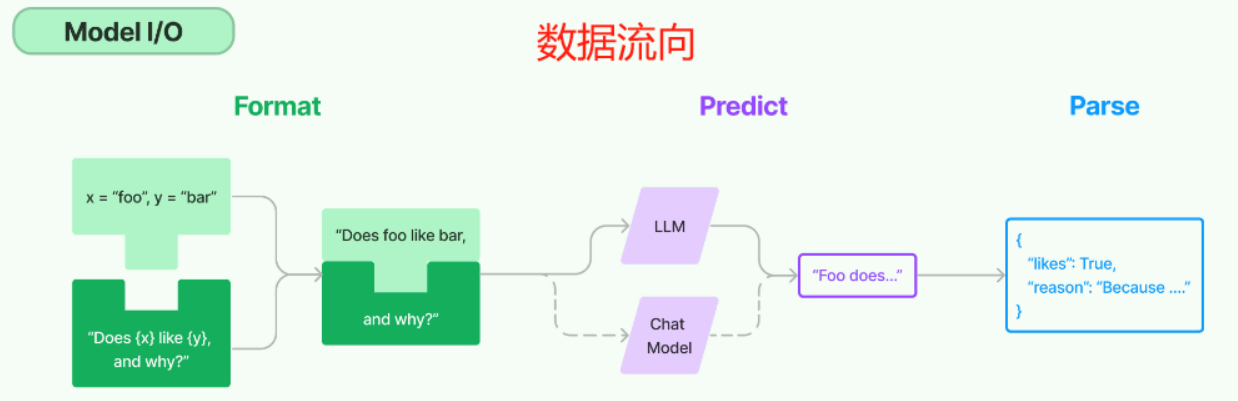

- Prompt：Prompt 是一个 BasePromptTemplate，这意味着它接受一个模板变量的字典并生成一个PromptValue 。PromptValue 可以传递给 model（它以字符串作为输入）或 ChatModel（它以消息序列作为输入）。
- Model：将 PromptValue 传递给 model。如果我们的 model 是一个 ChatModel，这意味着它将输出一个 BaseMessage 。
- OutputParser：将 model 的输出传递给 output_parser，它是一个 BaseOutputParser，意味着它可以接受字符串或 BaseMessage 作为输入。
- chain：我们可以使用 | 运算符轻松创建这个Chain。 | 运算符在 LangChain 中用于将两个元素组合在一起。

### LCEL介绍
在现代大语言模型（model）应用的构建中，LangChain 提供了一种全新的表达范式，被称为LCEL（LangChain Expression Language）。它不仅简化了模型交互的编排过程，还增强了组合的灵活性和可维护性。

LCEL，全称为 LangChain Expression Language，是一种专为 LangChain 框架设计的表达语言。它通过一种链式组合的方式，允许开发者使用清晰、声明式的语法来构建语言模型驱动的应用流程。

简单来说，LCEL 是一种“函数式管道风格”的组件组合机制，用于连接各种可执行单元（Runnable）。这些单元包括提示模板、语言模型、输出解析器、工具函数等。

#### 设计目的
LCEL 的设计初衷在于：

- 模块化构建：将模型调用流程拆解为独立、可重用的组件。
- 逻辑可视化：通过语法符号（如管道符 |）呈现出明确的数据流路径。
- 统一运行接口：所有 LCEL 组件都实现了 .invoke()、.stream()、.batch() 等标准方法，便于在同步、异步或批处理环境下调用。
- 脱离框架限制：相比传统的 Chain 类和 Agent 架构，LCEL 更轻量、更具表达力，减少依赖的“黑盒”逻辑。

#### LCEL核心分析
##### Runnable 接口
Runnable 是 LangChain 中所有链的通用接口，用于描述“可以执行的数据流节点”。用于构建所有链（Chain）组件。它代表“一个可以调用（运行）的流程单元”，无论是：

- 单个组件（如 prompt、model）
- 一个序列流程（如 prompt → model → parser）
- 并行、多路、多输入多输出的复合结构
只要实现了 Runnable 接口，它就可以像函数一样 .invoke()，或用管道符 | 组合。

在Runnable接口中定义了以下核心方法：

invoke(input)：同步执行，处理单个输入，最常用的方法

batch(inputs)：批量执行，处理多个输入，提升处理效率

stream(input)：流式执行，逐步返回结果，经典的使用场景是大模型是一点点输出的，不是一下返回整个结果，可以通过 stream() 方法，进行流式输出

ainvoke(input)：异步执行，用于高并发场景。

##### 管道运算符
这是 LCEL 最具特色的语法符号。多个 Runnable 对象可以通过 | 串联起来，形成清晰的数据处理链。例如：
```shell
prompt | model | parser
```
表示数据将依次传入提示模板、模型和输出解析器，最终输出结构化结果。
##### PromptTemplate 与 OutputParser
LCEL 强调组件之间的职责明确，Prompt 只负责模板化输入，Parser 只负责格式化输出，Model 只负责推理。

##### Runnable 类继承关系
分析LangChain源码可知，在 LangChain 的类结构中，顶层基类是 Runnable，用于定义所有可执行对象的统一接口，实现了把“执行一个逻辑单元”抽象为一个统一的运行单元。包括：

- invoke(input)：同步执行
- ainvoke(input)：异步执行
- batch(inputs)：批量执行
- stream(input)：流式输出
而 RunnableSerializable 在 Runnable 基础上增加 序列化/反序列化 能力，作为 LangChain 内部链路的父类基类。

我们常用的Prompt、Parser、LLM 都继承自这个类，因而它们都可以被组合进 Chain / Graph 中。


## 四、实验内容

### 4.1 顺序链（基础LCEL链式调用）

LangChain的一个典型链条由Prompt、Model、OutputParser组成，可以通过链（Chain）把它们顺序组合起来，让一个任务的输出成为下一个任务的输入。使用LCEL的管道运算符即可轻松构建。

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 创建聊天提示模板
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个{role}，请简短回答我提出的问题"),
    ("human", "请回答:{question}")
])

prompt = chat_prompt.invoke({"role": "AI助手", "question": "什么是LangChain"})
logger.info(prompt)

# 初始化Deepseek聊天模型
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 手动调用：逐步执行 prompt -> model -> parser
result = model.invoke(prompt)
logger.info(f"模型原始输出:\n{result}")

parser = StrOutputParser()
response = parser.invoke(result)
logger.info(f"解析后的结构化结果:\n{response}")
logger.info(f"结果类型: {type(response)}")

# LCEL链式调用：使用 | 管道运算符构建链
chain = chat_prompt | model | parser

# 执行链
result_chain = chain.invoke({"role": "AI助手", "question": "什么是LangChain"})
logger.info(f"Chain执行结果:\n {result_chain}")
logger.info(f"Chain执行结果类型: {type(result_chain)}")

### 4.2 分支链（RunnableBranch）

RunnableBranch可以完成LCEL中的条件分支判断，根据输入的不同采用不同的处理逻辑。示例中程序会根据用户输入中是否包含"日语"、"韩语"等关键词，来选择对应的提示词进行处理，再执行不同的逻辑分支。

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableBranch
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

# 构建三种语言的提示词模板
english_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个英语翻译专家，你叫小英"),
    ("human", "{query}")
])

japanese_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个日语翻译专家，你叫小日"),
    ("human", "{query}")
])

korean_prompt = ChatPromptTemplate.from_messages([
    ("system", "你是一个韩语翻译专家，你叫小韩"),
    ("human", "{query}")
])


def determine_language(inputs):
    """判断语言种类"""
    query = inputs["query"]
    if "日语" in query:
        return "japanese"
    elif "韩语" in query:
        return "korean"
    else:
        return "english"


model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

parser = StrOutputParser()

# 创建分支链：根据语言类型选择不同的处理流程
chain = RunnableBranch(
    (lambda x: determine_language(x) == "japanese", japanese_prompt | model | parser),
    (lambda x: determine_language(x) == "korean", korean_prompt | model | parser),
    (english_prompt | model | parser)  # 默认分支
)

# 测试查询
test_queries = [
    {'query': '请你用韩语翻译这句话:"见到你很高兴"'},
    {'query': '请你用日语翻译这句话:"见到你很高兴"'},
    {'query': '请你用英语翻译这句话:"见到你很高兴"'}
]

for query_input in test_queries:
    lang = determine_language(query_input)
    logger.info(f"检测到语言类型: {lang}")

    if lang == "japanese":
        prompt = japanese_prompt
    elif lang == "korean":
        prompt = korean_prompt
    else:
        prompt = english_prompt

    formatted_messages = prompt.format_messages(**query_input)
    logger.info("格式化后的提示词:")
    for msg in formatted_messages:
        logger.info(f"[{msg.type}]: {msg.content}")

    result = chain.invoke(query_input)
    logger.info(f"输出结果: {result}\n")

### 4.3 串行链（多步骤链式调用）

多次调用大模型，将多个步骤串联起来实现功能。例如先用第一个模型生成中文内容，再将输出传给第二个模型翻译成英文，实现端到端的多步骤处理。

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 子链1：中文介绍
prompt1 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用中文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
parser1 = StrOutputParser()
chain1 = prompt1 | model | parser1

# 子链2：翻译成英文
prompt2 = ChatPromptTemplate.from_messages([
    ("system", "你是一个翻译助手，将用户输入内容翻译成英文"),
    ("human", "{input}")
])
parser2 = StrOutputParser()
chain2 = prompt2 | model | parser2

# 组合成复合链：chain1输出 -> lambda包装 -> chain2输入
full_chain = chain1 | (lambda content: {"input": content}) | chain2

result = full_chain.invoke({"topic": "langchain"})
logger.info(result)

### 4.4 并行链（RunnableParallel）

并行链是指同时运行多个子链（Chain），并在它们都完成后汇总结果。适用于同时问多个问题并聚合结果、多个model同时工作取最优答案、多路径推理等场景。

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 并行链1：中文介绍
prompt1 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用中文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
parser1 = StrOutputParser()
chain1 = prompt1 | model | parser1

# 并行链2：英文介绍
prompt2 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用英文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
parser2 = StrOutputParser()
chain2 = prompt2 | model | parser2

# 创建并行链，同时执行中英文生成
parallel_chain = RunnableParallel({
    "chinese": chain1,
    "english": chain2
})

result = parallel_chain.invoke({"topic": "langchain"})
logger.info(result)

### 4.5 进阶用法

#### 4.5.1 函数转可执行链（RunnableLambda）

RunnableLambda可以把一个普通的Python函数（lambda或def）转换为一个可执行的链（Runnable），然后就可以像对待模型、Prompt、Parser一样，把它与其他组件用运算符连接。适用于添加自定义的格式化、过滤、映射等操作。

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)


def debug_print(x):
    """调试打印函数"""
    logger.info(f"中间结果:{x}")
    return {"input": x}


# 子链1：中文介绍
prompt1 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用中文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
parser1 = StrOutputParser()
chain1 = prompt1 | model | parser1

# 子链2：翻译成英文
prompt2 = ChatPromptTemplate.from_messages([
    ("system", "你是一个翻译助手，将用户输入内容翻译成英文"),
    ("human", "{input}")
])
parser2 = StrOutputParser()
chain2 = prompt2 | model | parser2

# 构建链：chain1 -> debug_print（RunnableLambda） -> chain2
full_chain = chain1 | debug_print | chain2

result = full_chain.invoke({"topic": "langchain"})
logger.info(f"最终结果:{result}")

#### 4.5.2 参数传递（RunnableParallel字典简写）

RunnableParallel是LangChain构建"多路并发数据流"的核心模块，能让检索、预处理等操作并行执行，并将结果无缝衔接到后续的LLM推理中。在LCEL表达式中，使用字典结构包裹并在管道符两侧的，都会自动包装成RunnableParallel。

In [ ]:
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()


def retrieval_doc(question):
    """模拟知识库检索"""
    logger.info(f"检索器接收到用户提出问题：{question}")
    return "你是一个说话风趣幽默的AI助手，你叫亮仔"


model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

prompt = ChatPromptTemplate.from_messages([
    ("system", "{retrieval_info}"),
    ("human", "请简短回答{question}")
])
parser = StrOutputParser()

# 使用字典简写构建RunnableParallel，将检索结果和问题同时传递给prompt
chain = {
            "retrieval_info": lambda x: retrieval_doc(x["question"]),
            "question": itemgetter("question")
        } | prompt | model | parser

result = chain.invoke({'question': '你是谁，什么叫LangChain？'})
logger.info(result)

#### 4.5.3 数据透传（RunnablePassthrough）

RunnablePassthrough的作用是将输入数据原样传递到下一个可执行组件，同时还能对传递的数据进行数据重组。通过方法可以向入参中添加新的属性，将新的数据继续向下传递。

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()


def retrieval_doc(question):
    """模拟知识库检索"""
    logger.info(f"检索器接收到用户提出问题：{question}")
    return "你是一个说话风趣幽默的AI助手，你叫亮仔"


model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

prompt = ChatPromptTemplate.from_messages([
    ("system", "{retrieval_info}"),
    ("human", "请简短回答{question}")
])
parser = StrOutputParser()

# 使用RunnablePassthrough.assign注入检索结果
chain = RunnablePassthrough.assign(retrieval_info=retrieval_doc) | prompt | model | parser

result = chain.invoke({'question': '你是谁，什么是LangChain'})
logger.info(result)

#### 4.5.4 图形化打印链图

LangChain支持通过内置的来生成链结构的"流程图"，非常适合调试和理解链的拓扑结构。需先安装依赖库。

In [ ]:
%pip install grandalf==0.8

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel
from langchain_deepseek import ChatDeepSeek
import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key)

# 并行链1：中文介绍
prompt1 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用中文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
parser1 = StrOutputParser()
chain1 = prompt1 | model | parser1

# 并行链2：英文介绍
prompt2 = ChatPromptTemplate.from_messages([
    ("system", "你是一个知识渊博的计算机专家，请用英文简短回答"),
    ("human", "请简短介绍什么是{topic}")
])
parser2 = StrOutputParser()
chain2 = prompt2 | model | parser2

# 创建并行链
parallel_chain = RunnableParallel({
    "chinese": chain1,
    "english": chain2
})

# 打印链的ASCII图形结构
parallel_chain.get_graph().print_ascii()

# 执行链
result = parallel_chain.invoke({"topic": "langchain"})
logger.info(f"最终结果:{result}")

## 五、实验总结

1. 使用  管道运算符构建了 Prompt → Model → Parser 顺序链，体验了 LCEL 声明式编程的简洁性
2. 通过 RunnableBranch 实现条件分支，理解了根据输入动态选择处理路径的实现方式
3. 将多个子链串联实现先生成再翻译的多步骤任务，掌握了串行链的数据传递机制
4. 使用 RunnableParallel 同时执行中英文生成，理解了并行链在多任务并发场景下的优势
5. 通过 RunnableLambda 将自定义函数接入链中，掌握了在链式调用中插入自定义逻辑的方法
6. 使用 RunnablePassthrough.assign 注入检索结果，体验了数据透传在 RAG 场景中的典型应用